In [1]:
import os
os.chdir('../../..')

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kmedoids 
import chemiscope

from rdkit import Chem
from rdkit.Chem import Draw
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from ase.data import covalent_radii
from ase.data.colors import jmol_colors
from ase.neighborlist import neighbor_list, natural_cutoffs, NeighborList
from ase.visualize.plot import plot_atoms
from ase.utils import rotate

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.helper_functions import get_structures
from config.configs import get_rattle

In [36]:
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]
qm9 = QM9Dataset(required_mol_ids=mol_ids, sampling_strategy="head")

qm9.load()
#rattle = get_rattle()
frames = qm9.run_stress_test(mol_ids=mol_ids, max_bond_rattle=0.2)
frames_rotated = qm9.run_stress_test(mol_ids=mol_ids, rotated=True)

2026-03-21 13:34:19.820 | INFO     | src.datasets:load:381 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-21 13:34:19.835 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.2Å, Max Angle Rattle=5.0°)...
2026-03-21 13:34:20.254 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-21 13:34:20.270 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test.xyz
2026-03-21 13:34:20.271 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.05Å, Max Angle Rattle=5.0°)...
2026-03-21 13:34:20.594 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-21 13:34:20.609 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test_rotated.xyz


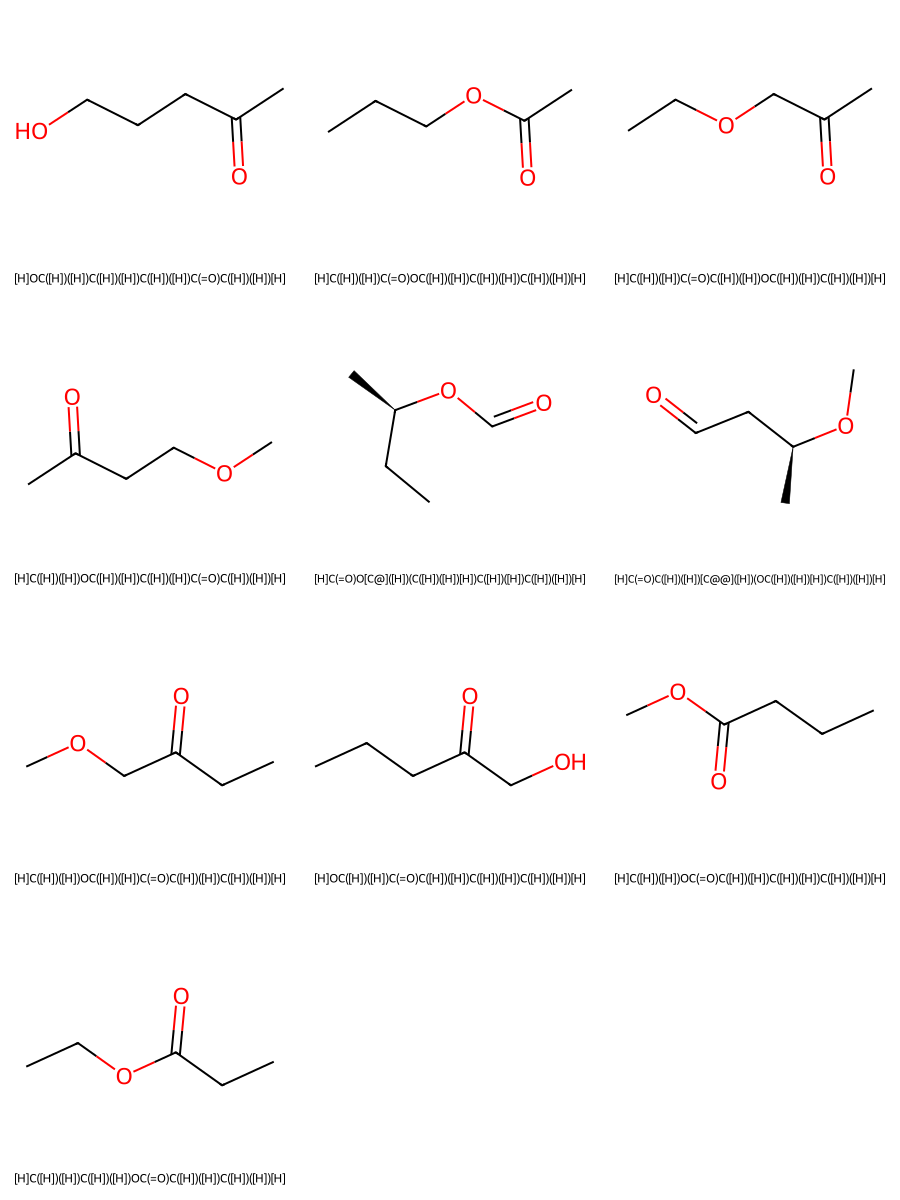

In [37]:
df = qm9.df.to_pandas()
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

sample_smiles = df[df["mol_id"].isin(mol_ids)]["canonical_smiles"].tolist()

mols = [Chem.MolFromSmiles(s) for s in sample_smiles]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=sample_smiles)
img

In [38]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

#print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 210 total frames.
qm9_1237
[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]


In [39]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_1237:
Max displacement: 0.5642 Å
Min displacement: 0.0000 Å
Average displacement: 0.2235 Å (Target was ~0.2)


In [40]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.3899 Å
Standard Deviation of bond length: 0.0527 Å


# Showing 5 versions of a rattled molecule

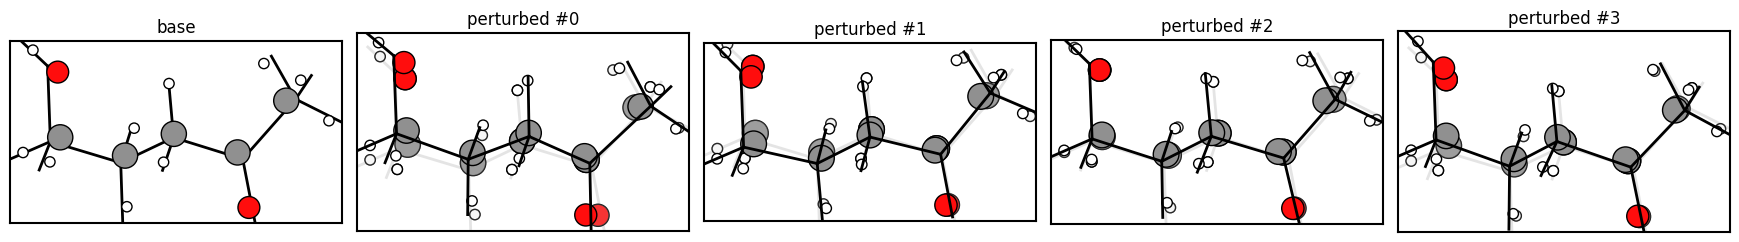

In [41]:
def get_2d_positions_from_patches(ax, n_atoms):
    """Extract atom center positions directly from what plot_atoms drew."""
    patches = ax.patches[-n_atoms:]
    return np.array([[p.center[0], p.center[1]] for p in patches])

def get_2d_positions_scaled(atoms, ax, rotation="0x,0y,0z"):
    rot = rotate(rotation)
    pos3d = atoms.get_positions() @ rot.T
    pos2d = pos3d[:, :2]
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_min, x_max = pos2d[:, 0].min(), pos2d[:, 0].max()
    y_min, y_max = pos2d[:, 1].min(), pos2d[:, 1].max()
    def scale(vals, v_min, v_max, ax_min, ax_max):
        if v_max == v_min:
            return np.full_like(vals, (ax_min + ax_max) / 2)
        return (vals - v_min) / (v_max - v_min) * (ax_max - ax_min) + ax_min
    x_scaled = scale(pos2d[:, 0], x_min, x_max, xlim[0], xlim[1])
    y_scaled = scale(pos2d[:, 1], y_min, y_max, ylim[0], ylim[1])
    return np.column_stack([x_scaled, y_scaled])

def draw_bonds(ax, atoms, pos2d, color='black', linewidth=2, alpha=1.0, zorder=0):
    cutoffs = natural_cutoffs(atoms, mult=1.1)
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    for i in range(len(atoms)):
        indices, _ = nl.get_neighbors(i)
        for j in indices:
            if j > i:
                ax.plot(
                    [pos2d[i, 0], pos2d[j, 0]],
                    [pos2d[i, 1], pos2d[j, 1]],
                    color=color, linewidth=linewidth,
                    alpha=alpha, zorder=zorder
                )

target_mol_id = frames[0].info["mol_id"]
mol_frames = [f for f in frames if f.info.get("mol_id") == target_mol_id]
base_frames = [f for f in mol_frames if f.info.get("frame_type") == "base"]
pert_frames = [f for f in mol_frames if f.info.get("frame_type") == "perturbed"]

base = base_frames[0]
perturbed = pert_frames[:4]

panels = [(None, base)] + [(p, base) for p in perturbed]
n = len(perturbed) + 1 

fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.5), subplot_kw={"aspect": "equal"})
if n == 1:
    axes = [axes]

for col, ax in enumerate(axes):
    if col == 0:
        plot_atoms(base, ax, radii=0.35, rotation="0x,0y,0z")
        pos2d = get_2d_positions_scaled(base, ax, rotation="0x,0y,0z")
        draw_bonds(ax, base, pos2d, color='black', linewidth=2, zorder=0)
        ax.set_title("base")

    else:
        pert = perturbed[col - 1]
        pidx = pert.info.get("perturbation_idx", col - 1)

        plot_atoms(base, ax, radii=0.35, rotation="0x,0y,0z")
        pos2d_base = get_2d_positions_scaled(base, ax, rotation="0x,0y,0z")

        draw_bonds(ax, base, pos2d_base, color='lightgray', linewidth=2, alpha=0.6, zorder=0)

        plot_atoms(base, ax, radii=0.35, rotation="0x,0y,0z")
        for patch in ax.patches[-len(base):]:
            patch.set_alpha(0.2)
            patch.set_facecolor('lightgray')
            patch.set_edgecolor('gray')

        plot_atoms(pert, ax, radii=0.35, rotation="0x,0y,0z")
        pos2d_pert = get_2d_positions_scaled(pert, ax, rotation="0x,0y,0z")
        draw_bonds(ax, pert, pos2d_pert, color='black', linewidth=2, zorder=1)

        ax.set_title(f"perturbed #{pidx}")

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

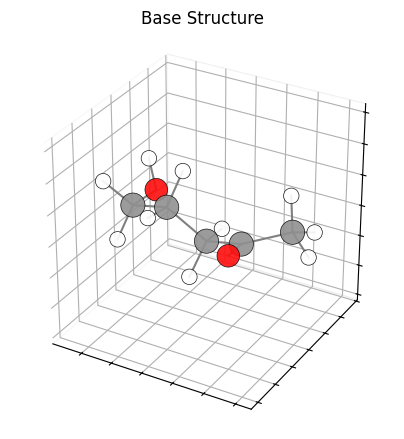

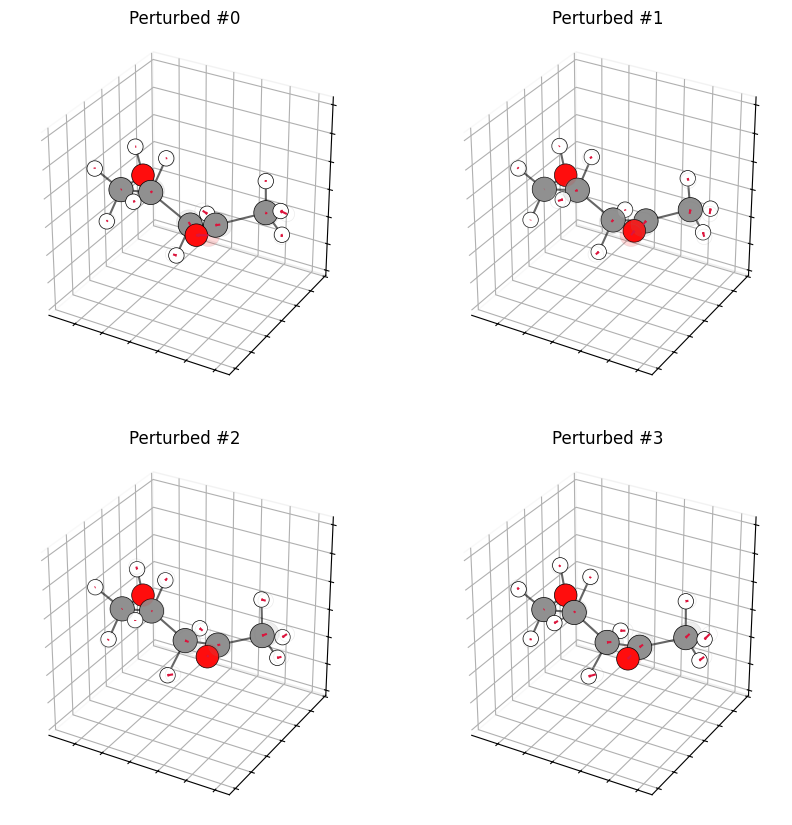

In [42]:
base = [f for f in frames if f.info.get("frame_type") == "base"][0]
base_pos = base.get_positions()
symbols = base.get_chemical_symbols()
numbers = base.get_atomic_numbers()

atom_colors = jmol_colors[numbers]
atom_sizes = covalent_radii[numbers] * 400 

cutoffs = covalent_radii[numbers] * 1.2
i_list, j_list = neighbor_list("ij", base, cutoffs)

perturbed = [f for f in frames if f.info.get("frame_type") == "perturbed"][:4]

all_positions = [base_pos] + [p.get_positions() for p in perturbed]
all_pos_array = np.vstack(all_positions)

max_range = np.array([
    all_pos_array[:, 0].max() - all_pos_array[:, 0].min(),
    all_pos_array[:, 1].max() - all_pos_array[:, 1].min(),
    all_pos_array[:, 2].max() - all_pos_array[:, 2].min()
]).max() / 2.0

mid_x = (all_pos_array[:, 0].max() + all_pos_array[:, 0].min()) * 0.5
mid_y = (all_pos_array[:, 1].max() + all_pos_array[:, 1].min()) * 0.5
mid_z = (all_pos_array[:, 2].max() + all_pos_array[:, 2].min()) * 0.5

def format_3d_axes(ax, title):
    """Helper function to apply locked limits and clean visual style."""
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    ax.set_box_aspect([1, 1, 1])

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(color='lightgray', linestyle=':', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.set_title(title, pad=10)

fig_base = plt.figure(figsize=(5, 5))
ax_base = fig_base.add_subplot(111, projection='3d')

for i, j in zip(i_list, j_list):
    if i < j:
        ax_base.plot(
            [base_pos[i, 0], base_pos[j, 0]],
            [base_pos[i, 1], base_pos[j, 1]],
            [base_pos[i, 2], base_pos[j, 2]],
            color="gray", linewidth=1.5, zorder=1
        )
ax_base.scatter(
    base_pos[:, 0], base_pos[:, 1], base_pos[:, 2],
    s=atom_sizes, c=atom_colors, edgecolors="black", 
    linewidth=0.5, alpha=0.9, zorder=2
)
format_3d_axes(ax_base, "Base Structure")

plt.show()

fig_pert = plt.figure(figsize=(10, 10))

for k, frame in enumerate(perturbed):
    ax = fig_pert.add_subplot(2, 2, k + 1, projection='3d')
    
    pos = frame.get_positions()
    disp = pos - base_pos

    ax.scatter(
        base_pos[:, 0], base_pos[:, 1], base_pos[:, 2],
        s=atom_sizes, c=atom_colors, edgecolors="gray", 
        linewidth=0.5, alpha=0.15, zorder=1
    )

    for i, j in zip(i_list, j_list):
        if i < j:
            ax.plot(
                [pos[i, 0], pos[j, 0]],
                [pos[i, 1], pos[j, 1]],
                [pos[i, 2], pos[j, 2]],
                color="black", linewidth=1.5, alpha=0.6, zorder=2
            )

    ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2],
        s=atom_sizes, c=atom_colors, edgecolors="black", 
        linewidth=0.5, alpha=1.0, zorder=3
    )

    ax.quiver(
        base_pos[:, 0], base_pos[:, 1], base_pos[:, 2],
        disp[:, 0], disp[:, 1], disp[:, 2],
        length=1.0, normalize=False, color="crimson", 
        linewidth=1.5, arrow_length_ratio=0.3, zorder=4
    )

    pidx = frame.info.get('perturbation_idx', k)
    format_3d_axes(ax, f"Perturbed #{pidx}")

plt.show()

In [43]:
import py3Dmol
import io

def get_xyz_str(atoms):
    """Convert ASE atoms to an XYZ string for py3Dmol."""
    f = io.StringIO()
    atoms.write(f, format='xyz')
    return f.getvalue()

n = len(perturbed) + 1
view = py3Dmol.view(viewergrid=(1, n), linked=True, width=350 * n, height=400)

view.addModel(get_xyz_str(base), 'xyz', viewer=(0, 0))
view.setStyle({'model': -1}, {'stick': {'radius': 0.15}, 'sphere': {'radius': 0.4}}, viewer=(0, 0))

for col, pert in enumerate(perturbed):
    v_idx = (0, col + 1)
    
    view.addModel(get_xyz_str(base), 'xyz', viewer=v_idx)
    view.setStyle({'model': -1}, 
                  {'stick': {'radius': 0.1, 'opacity': 0.6}, 
                   'sphere': {'radius': 0.2, 'opacity': 0.6}}, 
                  viewer=v_idx)
    
    view.addModel(get_xyz_str(pert), 'xyz', viewer=v_idx)
    view.setStyle({'model': -1}, 
                  {'stick': {'radius': 0.15, 'colorscheme': 'cyanCarbon'}, 
                   'sphere': {'radius': 0.4, 'colorscheme': 'cyanCarbon'}}, 
                  viewer=v_idx)

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Clustering

In [45]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean"):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info.get('smiles', '') for f in frames]
    base_or_pertubated = [f.info.get('frame_type', '') for f in frames]

    unique_mol_ids = list(set(true_labels))
    n_clusters = len(unique_mol_ids)

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")
        
        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)
        
        tsne = TSNE(
            n_components=2, 
            metric='precomputed', 
            init='random', 
            random_state=42, 
            perplexity=30
        )
        X_tsne = tsne.fit_transform(dist_matrix)
        
        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(frames)
            suffix = "raw"
            
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(
            n_components=2, 
            random_state=42, 
            perplexity=30, 
            init='pca'
        )
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"\nClustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print("\nCluster Composition Summary:")
    display(summary_table)

    structures, _ = get_structures(qm9.df, mol_id_list=true_labels)
    structures = [s for s in structures for _ in range(21)]

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )
    
    print(f"\nChemiscope file successfully saved to: {output_path}")

    return summary_table, output_path

In [46]:
summary_table_inv, output_path_inv = make_clustering(frames, rotational_invariant=True)

chemiscope.show_input(output_path_inv)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [invariant]: 0.7203

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,3,"[""qm9_1237"", ""qm9_1246"", ""qm9_1476""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
1,2,"[""qm9_1244"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",20
2,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
3,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
4,4,"[""qm9_1237"", ""qm9_1246"", ""qm9_1476"", ""qm9_1478""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",19
5,2,"[""qm9_1244"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
7,2,"[""qm9_1246"", ""qm9_1478""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",20
8,4,"[""qm9_1237"", ""qm9_1244"", ""qm9_1246"", ""qm9_1476""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",25



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_invariant.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_invariant'}, structures=[{'size': 17, 'data': 'structur…

In [47]:
summary_table, output_path = make_clustering(frames, rotational_invariant=False)

chemiscope.show_input(output_path)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [raw]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
1,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
2,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
3,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
4,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_raw.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_raw'}, structures=[{'size': 17, 'data': 'structure-0'},…

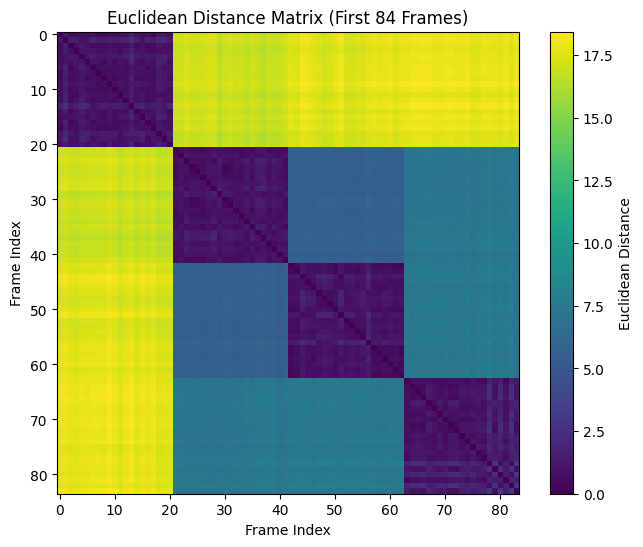

Using precomputed euclidean_precomputed distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [euclidean_precomputed]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
2,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
3,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
5,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean_precomputed.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean_precomputed'}, structures=[{'size': 17, 'data…

In [48]:
from sklearn.metrics import pairwise_distances

X_euclidean = get_raw_xyz_features(frames)
dist_matrix_euclidean = pairwise_distances(X_euclidean, metric='euclidean')

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix_euclidean[:84, :84], cmap='viridis')
plt.colorbar(label='Euclidean Distance')
plt.title("Euclidean Distance Matrix (First 84 Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

summary_eucl, path_eucl = make_clustering(
    frames, 
    dist_matrix=dist_matrix_euclidean, 
    metric_name="euclidean_precomputed",
)

chemiscope.show_input(path_eucl)